# Importing libraries and data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from the adjacent 'Data' directory
df = pd.read_csv('../Data/Sleep_health_and_lifestyle_dataset.csv')

print('Fist five rows')
df.head()


Fist five rows


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# Observations

In [2]:
#Check the dataset's data types, the number of records, column names and missing values
print('info')
df.info()

#Check summary statistics
print("\ndescribe")
df.describe()

info
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB

describe


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


# Hypotheses

1. Stress directly decreases the sleep quality by making it harder to fall asleep, due to high heart rate and anxiety<br>
2. Stress degrades sleep quality (the sleep becomes superficial), while  the sleep quantity may remain unchanged or even increase, because the body tries to compensate for fatigue by staying in bed longer <br>


## Initial observations
To investigate our hypotheses, we grouped the dataset by `Stress Level` and calculated the mean values for all numberic fields. <br>
This allows us to observe general trends and see how changes in stress correspond to sleep metrics and demographics. <br>

In [39]:
agr_data_by_stress_level = df.groupby(by='Stress Level').mean(numeric_only=True)
agr_data_by_stress_level = agr_data_by_stress_level.drop(columns='Person ID')
agr_data_by_stress_level

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Heart Rate,Daily Steps
Stress Level,,,,,,
3,54.169014,8.226761,8.971831,54.718310,67.098592,6132.394366
4,39.900000,7.030000,7.671429,55.785714,66.828571,6422.857143
5,40.313433,7.483582,7.895522,74.253731,70.074627,7616.417910
6,33.065217,7.454348,7.000000,67.152174,70.717391,7363.043478
7,42.680000,6.468000,6.000000,43.840000,73.300000,5662.000000
8,39.742857,6.050000,5.857143,58.342857,74.100000,7605.714286


### Key observations from the table:
- **Sleep duration trend:** As stress increases, there is a clear downward trend in sleep hours. The most significant drop is between stress levels 3 and 4.
- **The quality vs. quantity paradox:** Between stress levels 5 and 6, the average sleep duration remains almost identical (~7.45 hours), yet the subjective `Quality of Sleep` drops from 7.89 to 7.00. This provides early, indirect support for our second hypothesis.
- **Age and stress:** It is worth noting, the least stressed group (level 3) has the highest average age (~54 years), while the group with the lowest average age (~33 years) is found at stress level 6.

Text(0, 0.5, 'Average Quality of Sleep (4-9)')

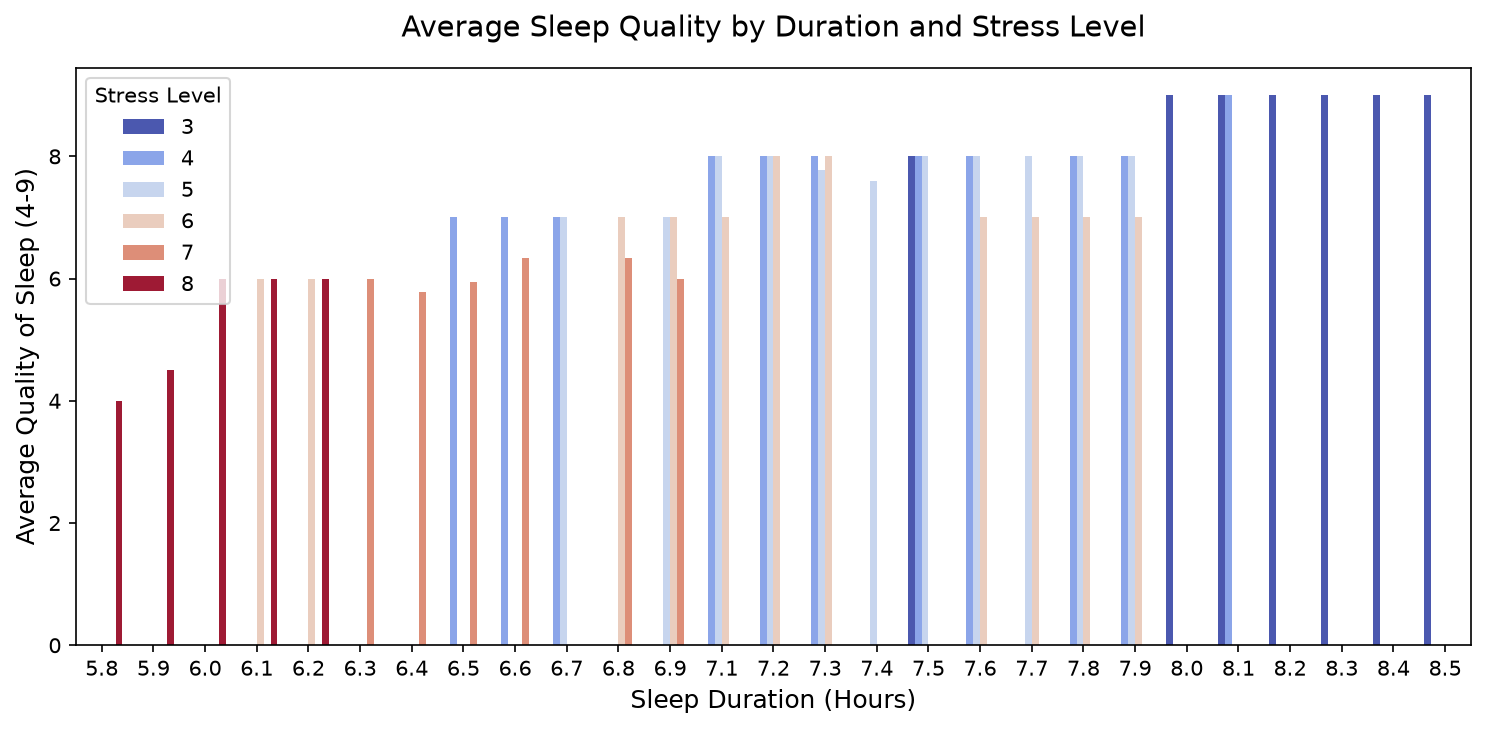

In [5]:
plt.figure(figsize=(12, 5), dpi=150)
sns.barplot(data = df, x='Sleep Duration', y ='Quality of Sleep', hue = 'Stress Level', palette='coolwarm', estimator=np.mean, errorbar=None)

plt.title('Average Sleep Quality by Duration and Stress Level', fontsize=14, pad=15)
plt.xlabel('Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Average Quality of Sleep (4-9)', fontsize=12)

### Key observations from the barplot:
While the aggregated table showed general trends, this bar chart reveals the distribution of the data and provides us with new observations: <br>

- **The volatility of stress level 6:** The chart highlights that people who estimated their stress level at '6' have a sleep duration from just over 6 hours (6.1) to almost 8 hours (7.9). This might mean that, regardless of how much extra time they spend in bed, their subjective `Quality of Sleep` never exceeds 8. This strongly strengthens **Hypothesis #2** (the sleep remains superficial and fails to recover efficiency).

- **The critical threshold (sleep < 6h):** Interestingly, individuals who sleep less than 6 hours exclusively estimated their stress level at '8', which is the maximum value in this dataset.

- **Data limitation note:** It is important to highlight a dataset limitation. The exact metrics and boundaries of the `Stress Level` scale are not fully documented (we only observe values from 3 to 8). The same situation applies to `Quality of Sleep`, where we only observe values between 4 and 9.


## Investigation of the correlation between `Stress Level` and `Heart Rate` (Hypothesis #1) 
To investigate our first hypothesis we'll take the following steps: <br>
1. Check for a correlation between `Stress Level` and `Heart Rate`
2. Check for a correlation between `Heart Rate` and both `Sleep Duration` and `Quality of Sleep`
3. Check for a correlation between `Stress Level` and `Sleep Disorder`

This will help us understand whether there is a physiological mechanism behind stress and see if a high heart rate impacts sleep quality and duration.

In [16]:
df[['Sleep Duration', 'Stress Level','Quality of Sleep','Heart Rate','Physical Activity Level','Daily Steps','Age']].corr()

,Sleep Duration,Stress Level,Quality of Sleep,Heart Rate,Physical Activity Level,Daily Steps,Age
Sleep Duration,1.000000,-0.811023,0.883213,-0.516455,0.212360,-0.039533,0.344709
Stress Level,-0.811023,1.000000,-0.898752,0.670026,-0.034134,0.186829,-0.422344
Quality of Sleep,0.883213,-0.898752,1.000000,-0.659865,0.192896,0.016791,0.473734
Heart Rate,-0.516455,0.670026,-0.659865,1.000000,0.136971,-0.030309,-0.225606
Physical Activity Level,0.212360,-0.034134,0.192896,0.136971,1.000000,0.772723,0.178993
Daily Steps,-0.039533,0.186829,0.016791,-0.030309,0.772723,1.000000,0.057973
Age,0.344709,-0.422344,0.473734,-0.225606,0.178993,0.057973,1.000000


### Key observations from the table:
- **Correlation between stress level and heart rate:** We see the positive correlation coefficient between `Stress Level` and `Heart Rate` equals 0.67. It quantitatively supports the idea that a person's physiological state is highly related to their psychological state. 
- **A notable side insight:** Surprisingly, `Physical Activity Level` and `Stress Level` barely correlate (standing at just -0.03).
- **Age and stress:** Meanwhile, `Age` and `Stress Level` have a negative correlation (-0.42) that means older people experience less stress than younger ones in these data.

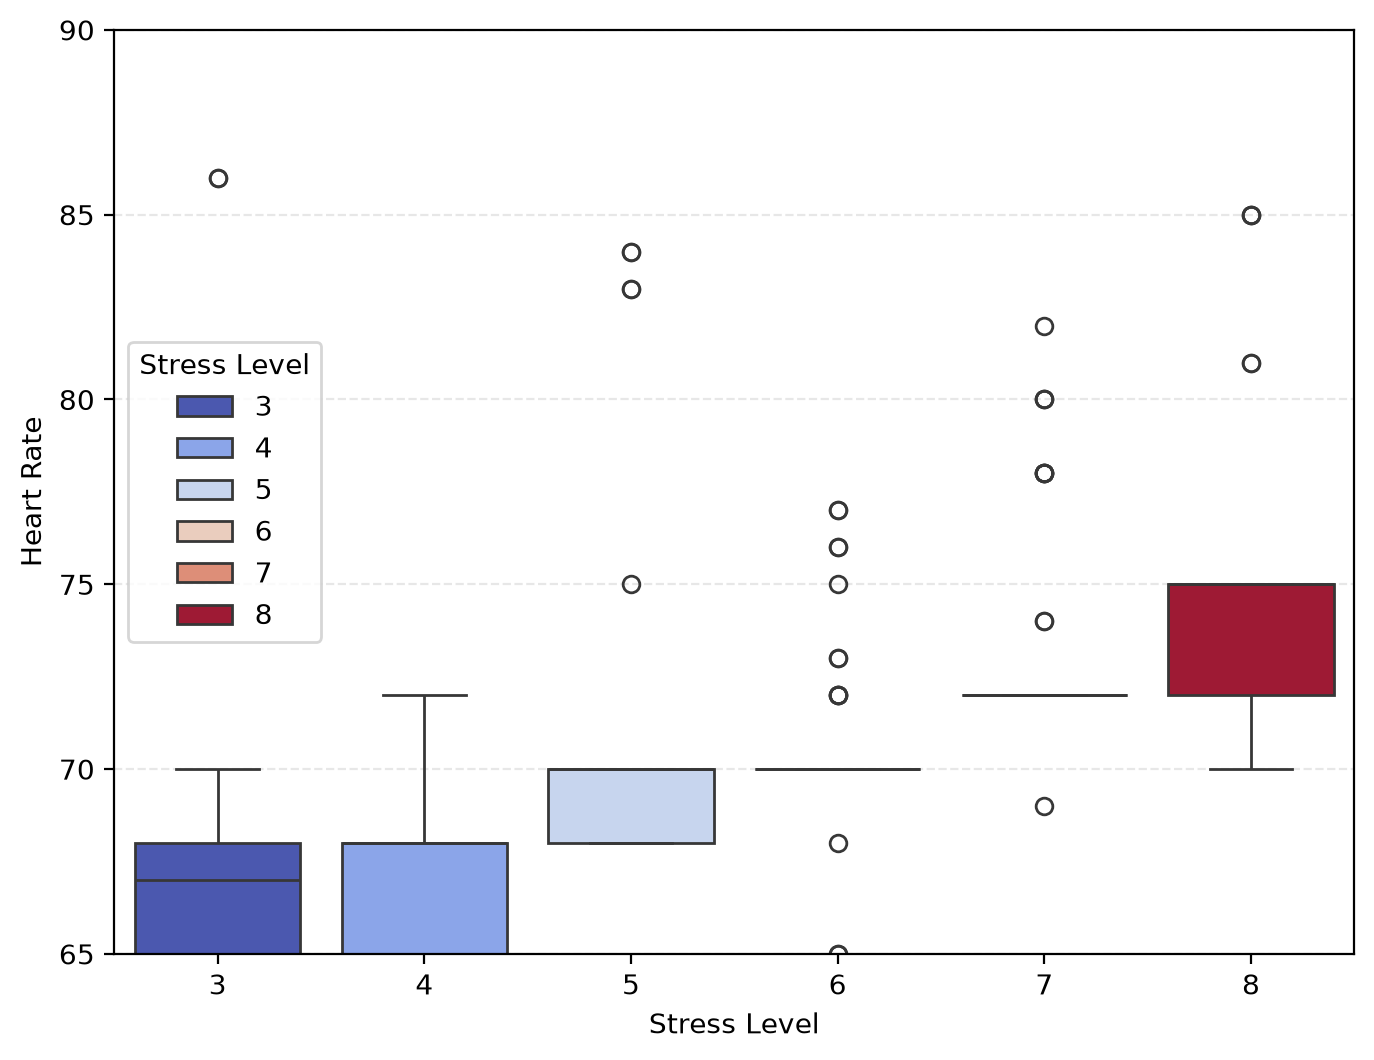

In [17]:
plt.figure(figsize=(8,6), dpi=200)
sns.boxplot(data=df, x='Stress Level', y = 'Heart Rate', hue = 'Stress Level', palette = 'coolwarm')
plt.ylim(65,90)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

### Key observations from the boxplot:
- **Plot paradox:** The heart rate data in this dataset seems to be rounded because we observe groups of people clusterd around values like 60/70/75 beats per minute. 
- **This boxplot:** There is low variability of data, so we see the median merges with the box borders on several stress level. 
- **Next step:** To smooth this rounding effect and see at least agregation trend we decided to use a barplot that shows average heart rate.

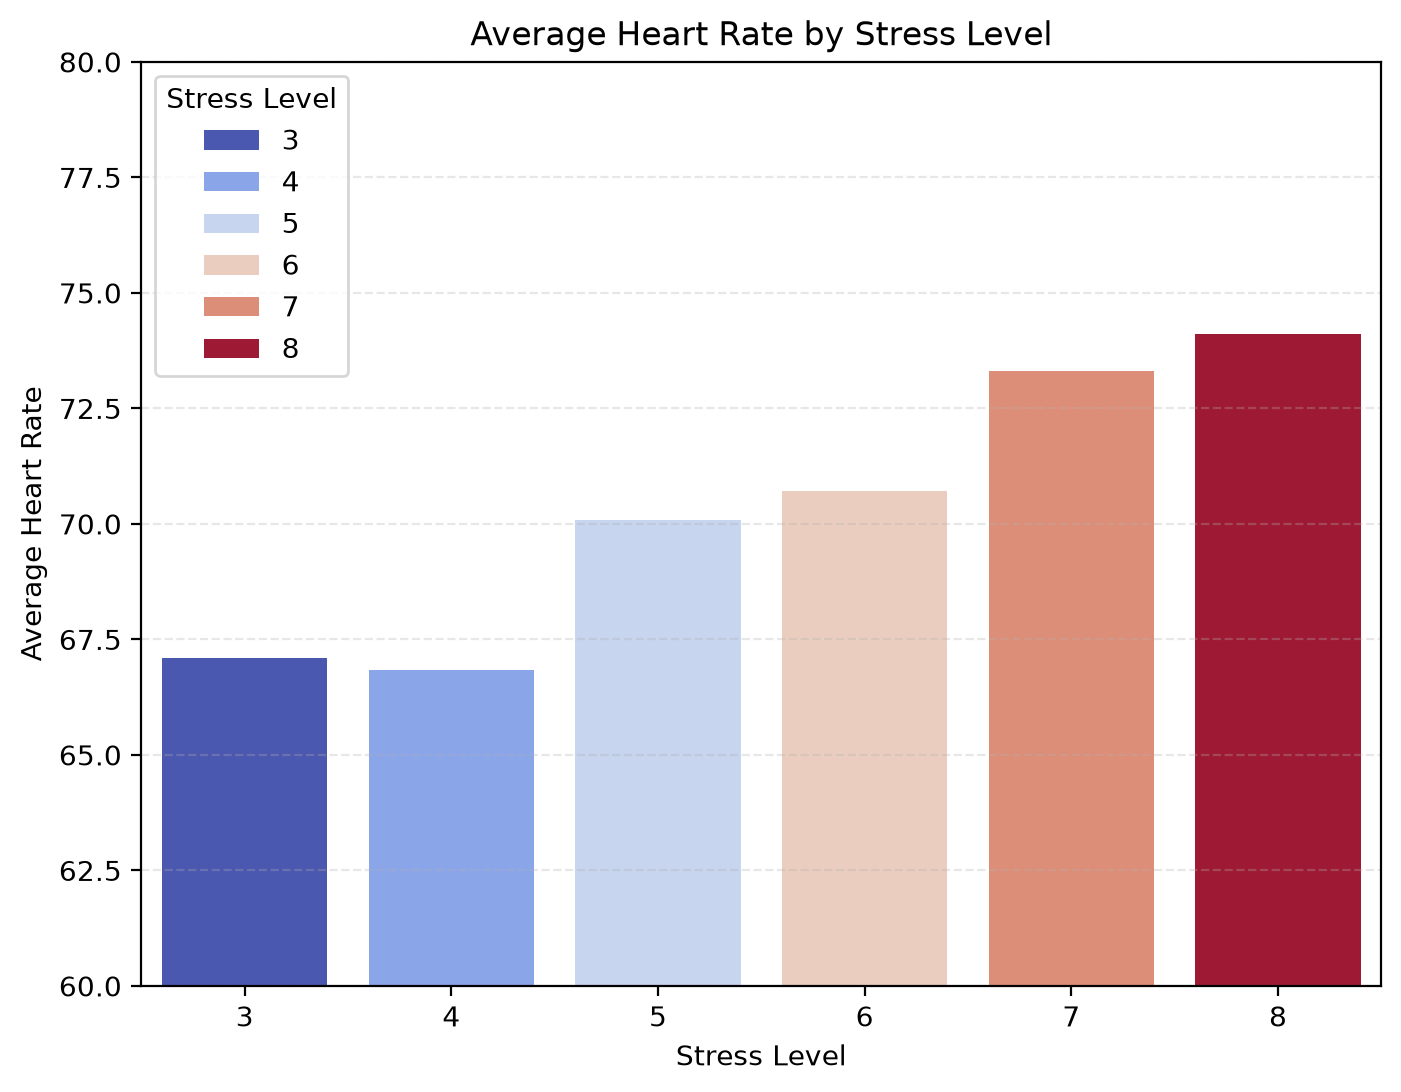

In [18]:
plt.figure(figsize=(8,6), dpi=200)
sns.barplot(data=df, x='Stress Level', y = 'Heart Rate', hue = 'Stress Level', palette = 'coolwarm', errorbar = None)
plt.ylim(60,80)
plt.ylabel('Average Heart Rate')
plt.title ('Average Heart Rate by Stress Level')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

### Key observations from the barplot:
- **Avg. heart rate and stress level:** We observe the mean heart rate increases with the stress level. Individuals with low stress levels (3-4) have a heart rate of about 67 bpm, at medium stress levels (5-6) the heart rate rises to 70 bpm, and at high stress levels (7-8) it rises up to 73 bpm.
- **Conclusion:**  These results partially support the first part of the Hypothesis #1. There is a physiological relationship - a high stress level positively correlates with a high heart rate. 

In [19]:
df[['Heart Rate', 'Sleep Duration', 'Quality of Sleep']].corr()

,Heart Rate,Sleep Duration,Quality of Sleep
Heart Rate,1.000000,-0.516455,-0.659865
Sleep Duration,-0.516455,1.000000,0.883213
Quality of Sleep,-0.659865,0.883213,1.000000


Text(0.5, 1.0, 'Heart rate by sleep duration')

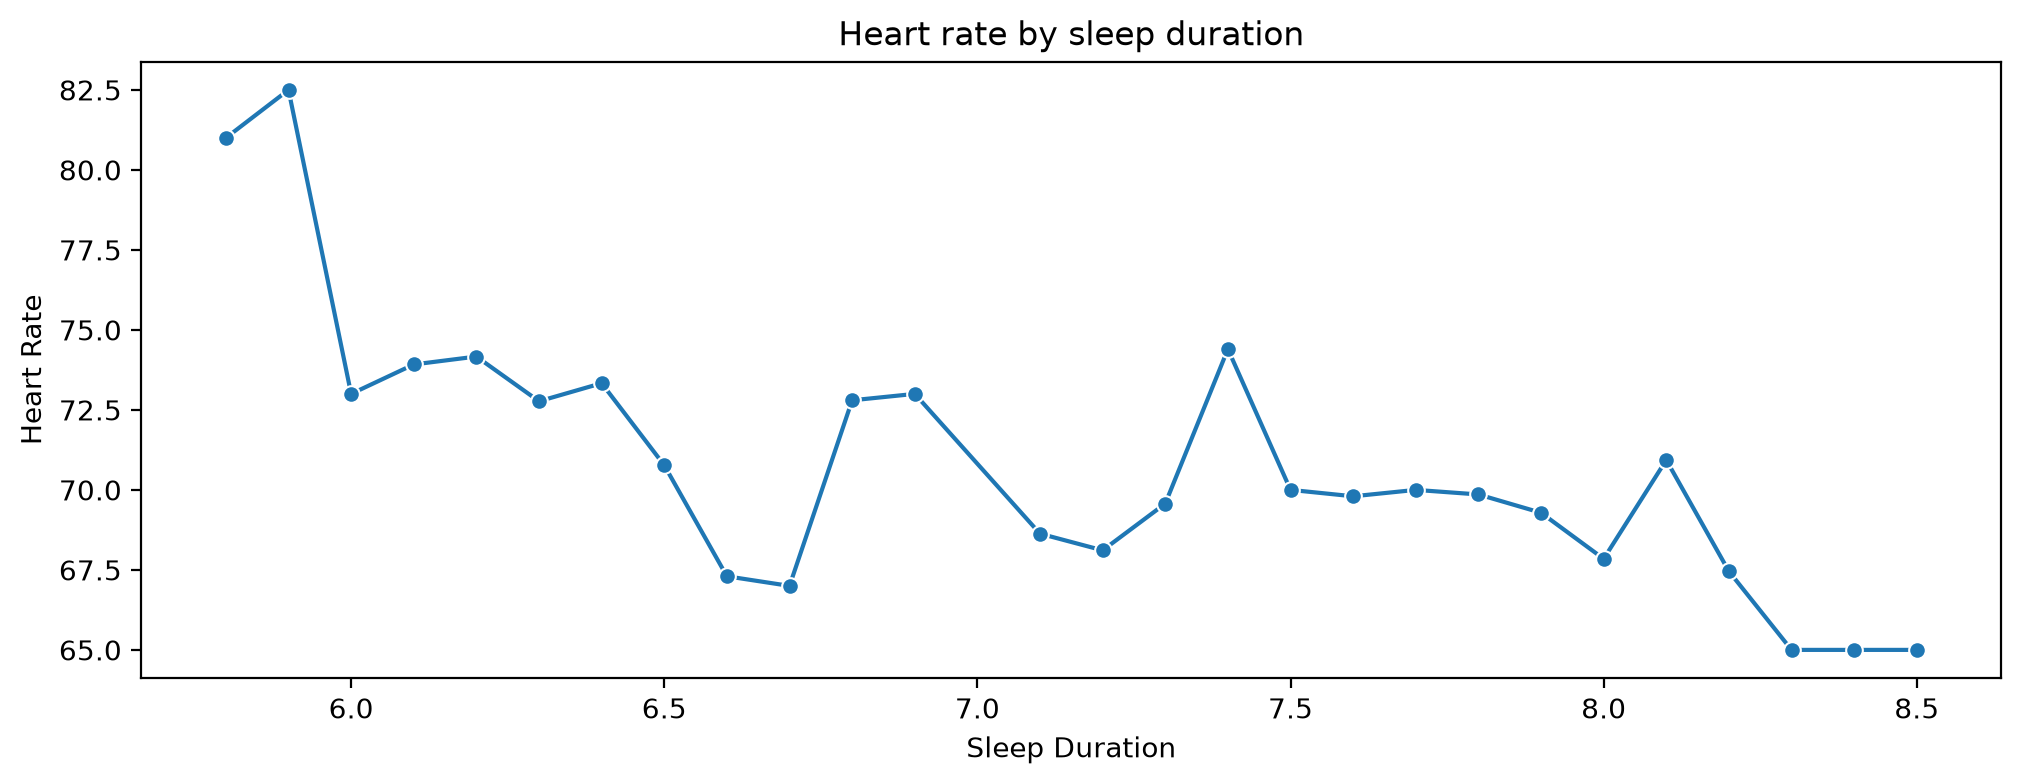

In [20]:
plt.figure(figsize=(12,4), dpi=200)
sns.lineplot(data=df, x='Sleep Duration', y= 'Heart Rate',  marker='o', errorbar=None)
plt.title('Heart rate by sleep duration')

Text(0.5, 1.0, 'Heart rate by quality of sleep')

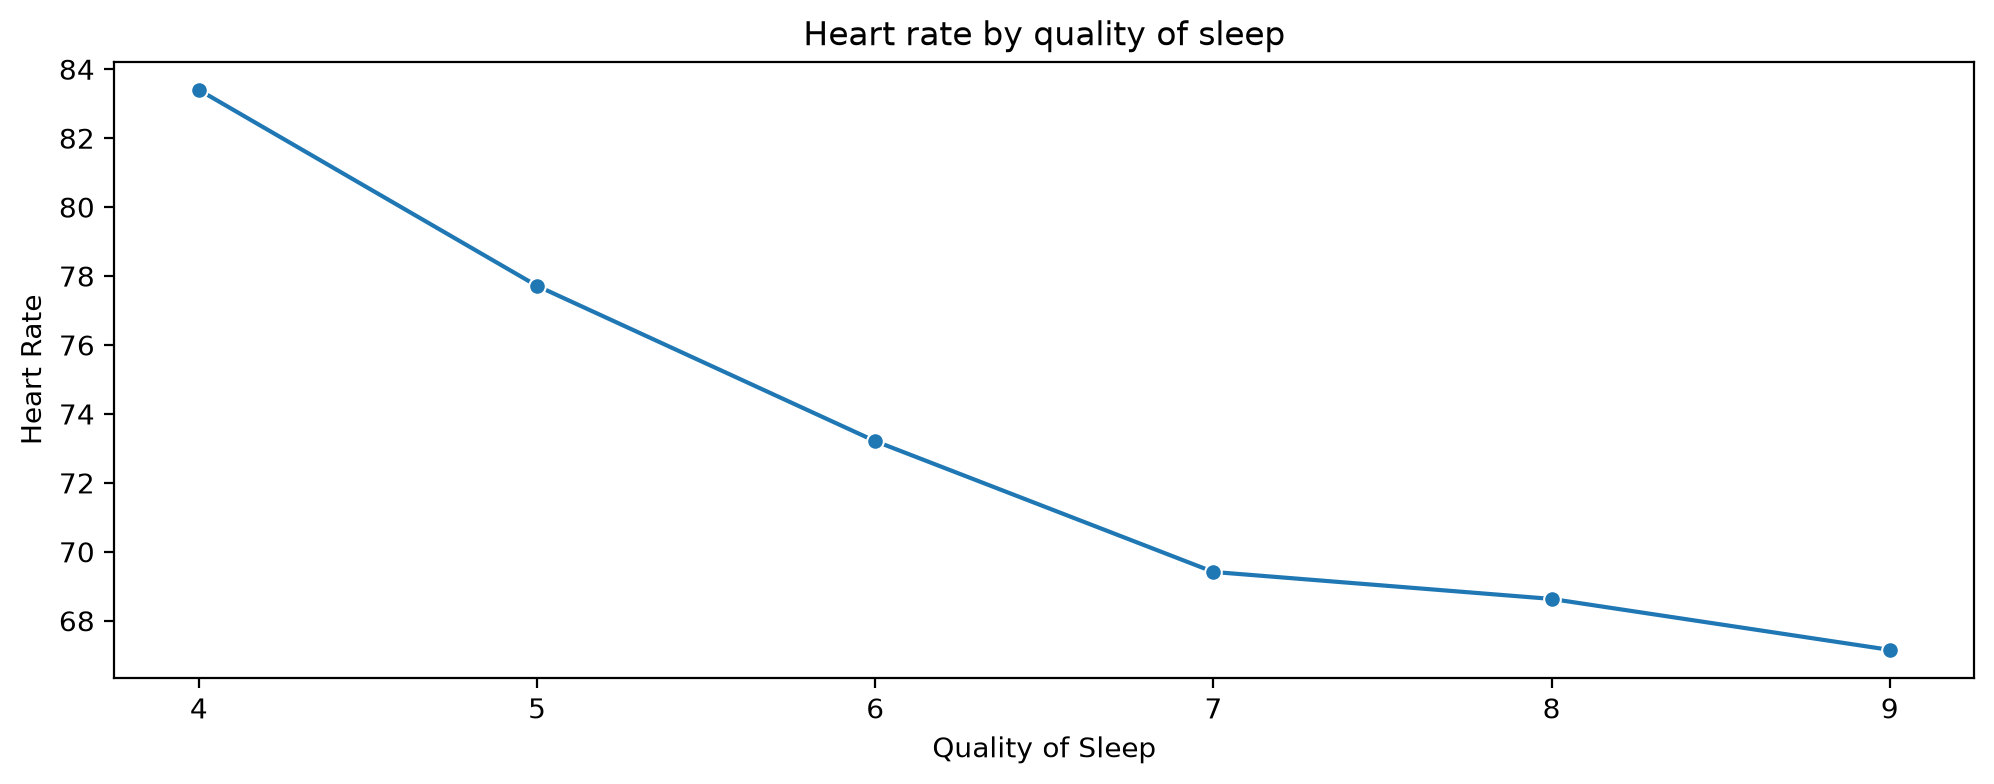

In [21]:
plt.figure(figsize=(12,4), dpi=200)
sns.lineplot(data=df, x='Quality of Sleep', y= 'Heart Rate', marker='o', errorbar=None)
plt.title('Heart rate by quality of sleep')

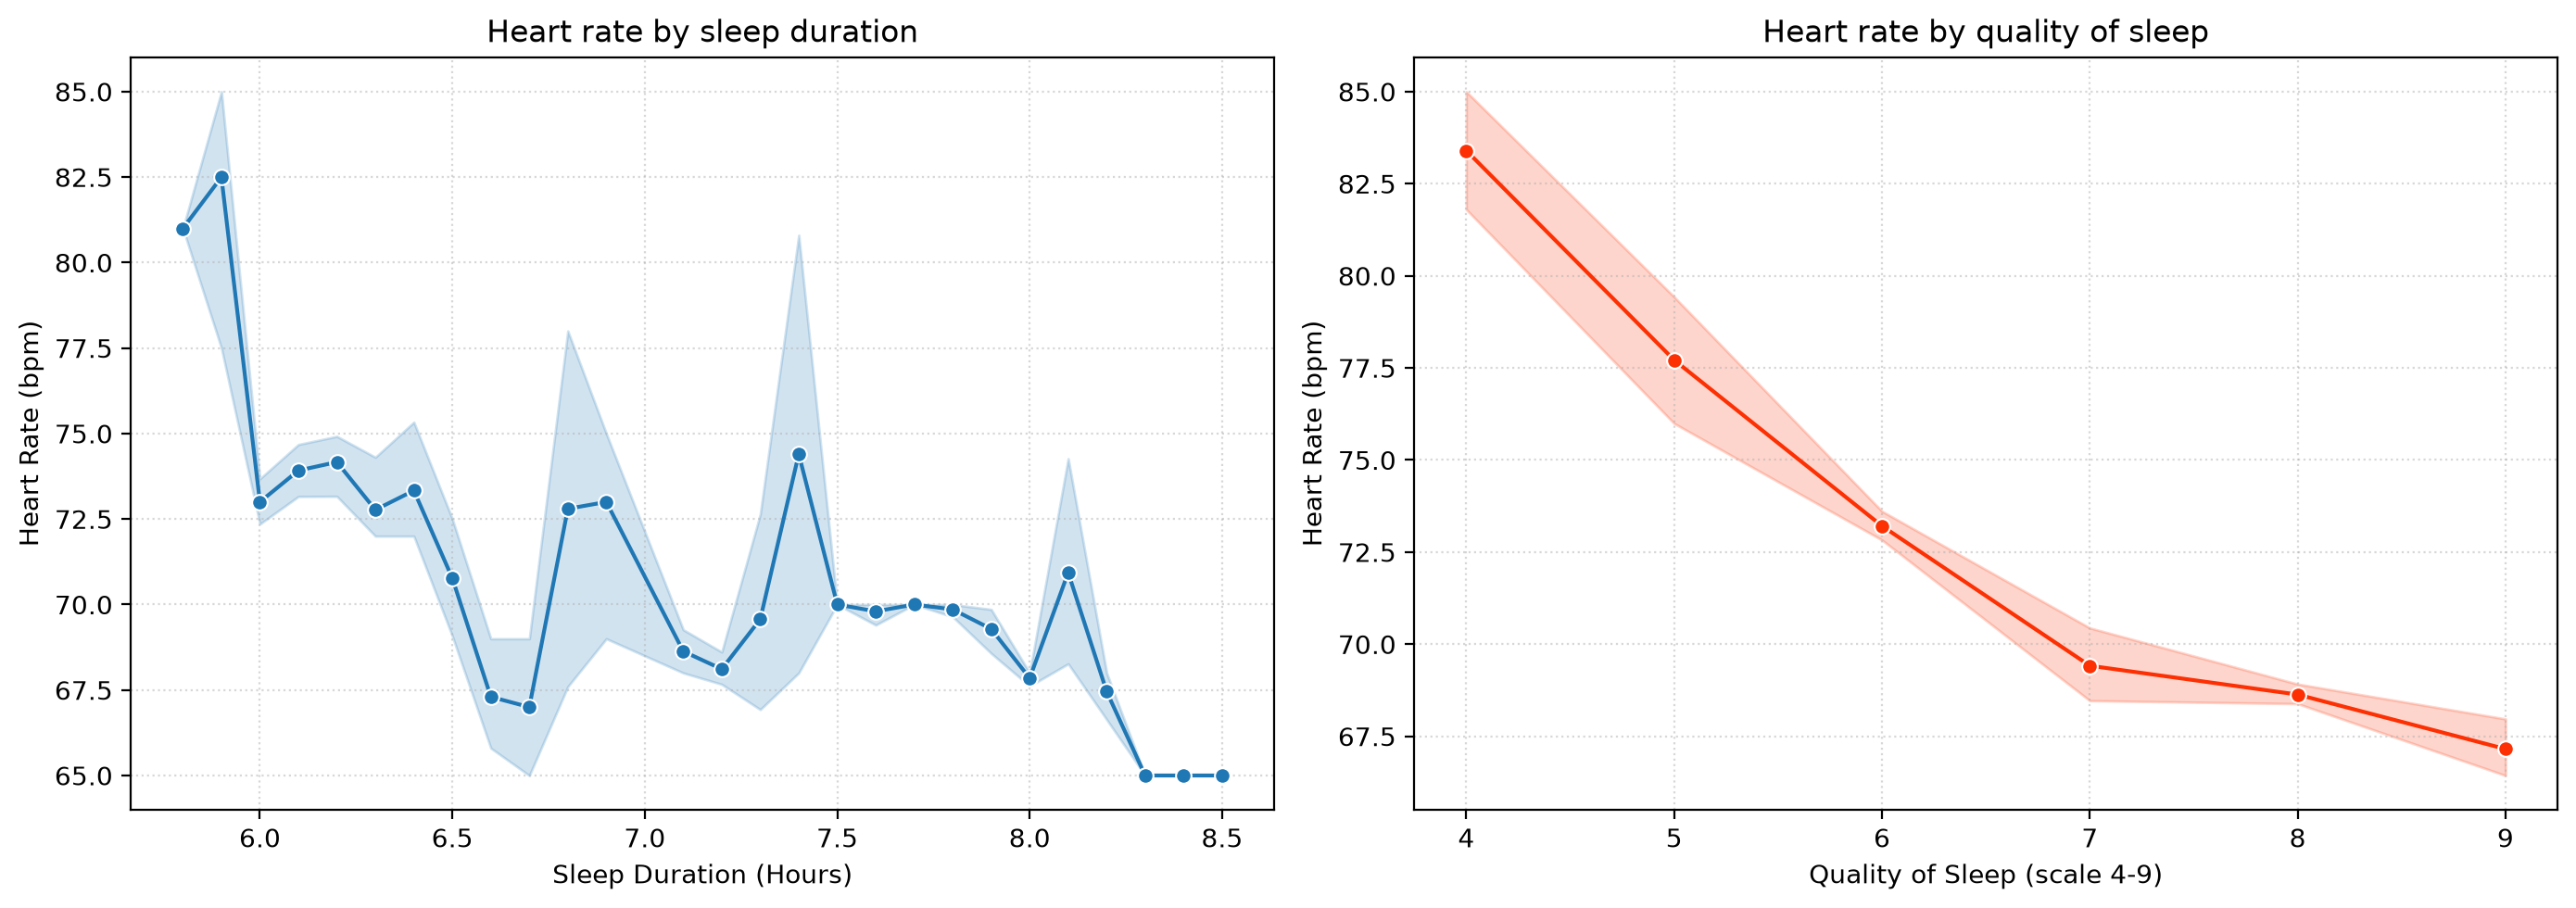

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

# 1. Sleep duration vs Heart Rate
sns.lineplot(data=df, x='Sleep Duration', y= 'Heart Rate', marker='o', ax=axes[0])
axes[0].set_title('Heart rate by sleep duration')
axes[0].set_xlabel('Sleep Duration (Hours)')
axes[0].set_ylabel('Heart Rate (bpm)')
axes[0].grid(True, alpha = 0.5, linestyle = ':')

# 2. Sleep quality vs Heart Rate
sns.lineplot(data=df, x='Quality of Sleep', y= 'Heart Rate',marker='o', ax=axes[1], color = '#fc3003')
axes[1].set_title('Heart rate by quality of sleep')
axes[1].set_xlabel('Quality of Sleep (scale 4-9)')
axes[1].set_ylabel('Heart Rate (bpm)')
axes[1].grid(True, alpha = 0.5, linestyle = ':')

plt.tight_layout()

### Key observations from the second step:

*   **Correlation with sleep quality:** There is a strong negative relationship between heart rate and sleep quality. Individuals with low sleep quality (rating 4) have a mean heart rate of **~83 bpm**, while those with high sleep quality (rating 8–9) have a much lower heart rate of **67–68 bpm**.
*   **Correlation with sleep duration:** Overall, longer sleep means a lower resting heart rate, dropping from **~81–83 bpm** (under 6 hours) down to **65 bpm** (8.5 hours). 
*   **Data anomaly:** We can see two clear spikes in heart rate (up to **~75 bpm**) at **6.8–6.9** and **7.4 hours** of sleep, along with a wider confidence interval. This suggests other factors, like high stress levels in this group.
*   **Conclusion:** The results fully support Hypothesis #1. Poor sleep quality and short sleep duration are strong indicators of a higher resting heart rate.

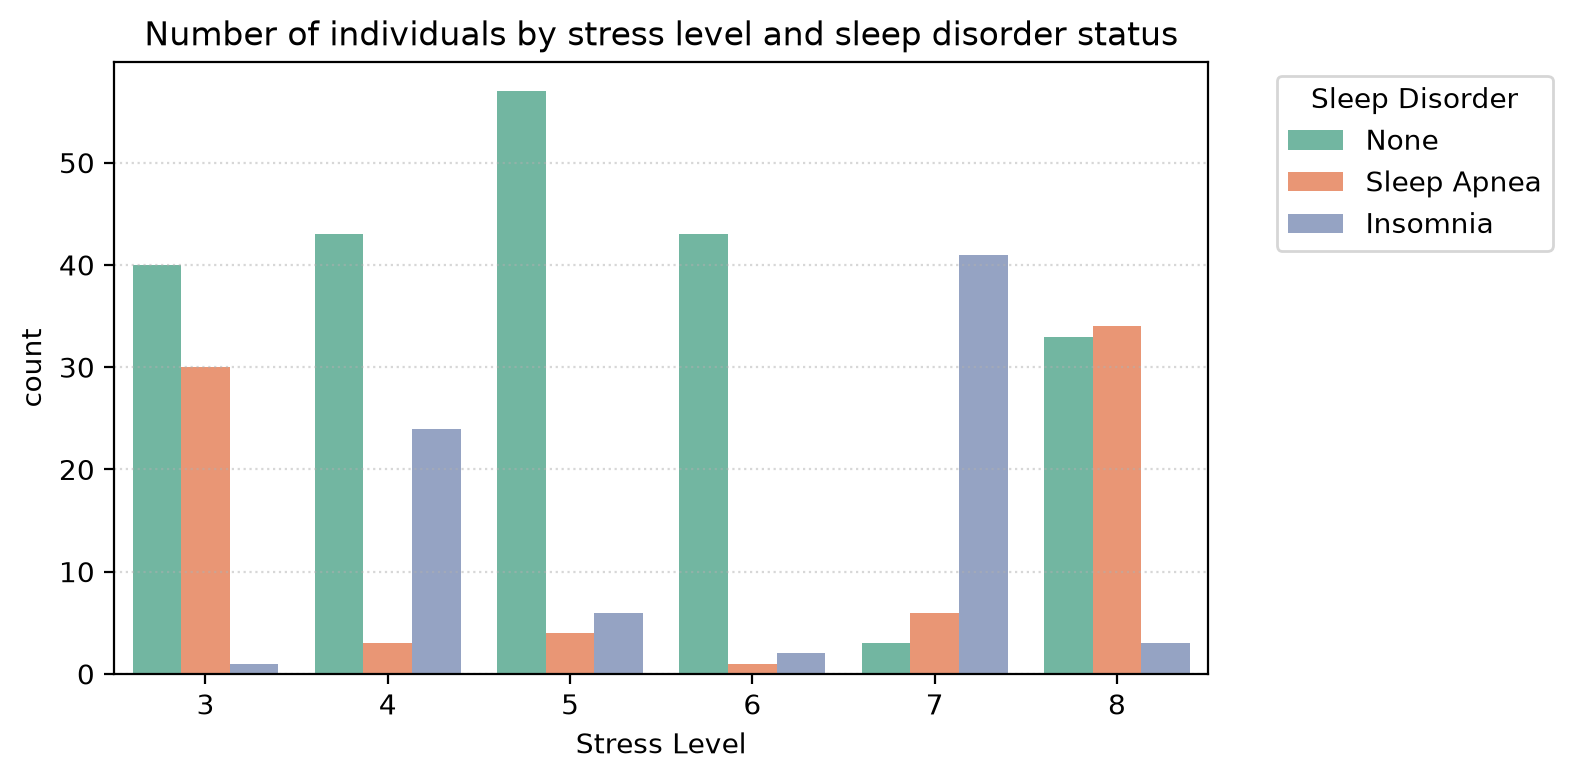

In [4]:
#We need to investigate the relationship between stress level and sleep disorder but we have NaN values for those who don't have any sleep disorder
#To correct that we need to transform our data.
df_without_nan = df.copy()
df_without_nan['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
plt.figure(figsize=(8,4), dpi=200)
sns.countplot(data=df_without_nan, x='Stress Level', hue='Sleep Disorder', palette='Set2')
plt.title('Number of individuals by stress level and sleep disorder status')
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc= 'upper left')
plt.grid(axis='y', linestyle = ':', alpha = 0.5 )
plt.tight_layout()

### Key observations from the plot:

*   **Low to moderate stress (levels 3–6):** Most people in this group don't have any sleep disorders (`None`). However, there're spikes for `Sleep Apnea` at level 3 and `Insomnia` at level 4.
*   **High stress anomaly (level 7):** Individuals without sleep disorders are almost absent (less than 10 people). Instead, there is a massive peak in `Insomnia` (>40 cases), showing a strong link between high stress and insomnia but then at level 8 there are a few people with `Insomnia`, which looks like an anomaly.
*   **Extreme stress (level 8):** `Insomnia` drops sharply, while `Sleep Apnea` and healthy individuals (`None`) increase again, which suggests that factors other than stress (e.g., age or occupation) might influence this group.
*   **Conclusion:** There is no strong relationship between stress levels and sleep disorders. Instead, we observe the following: `Insomnia` is mainly concentrated at level 7 (high level) and appears at level 4 (low level), while `Sleep Apnea` appears at both low (level 3) and high (level 8) stress levels. 

Let's look at median values for other properties to see if we can notice a new pattern

In [24]:
columns_to_show = ['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Heart Rate', 'Age']
df_without_nan.groupby(by='Sleep Disorder')[columns_to_show].describe().transpose()
#We got nothing here

Sleep Disorder           Insomnia        None  Sleep Apnea
Sleep Duration   count  77.000000  219.000000    78.000000
                 mean    6.589610    7.358447     7.032051
                 std     0.387157    0.732320     0.974812
                 min     5.900000    6.000000     5.800000
                 25%     6.400000    7.100000     6.100000
                 50%     6.500000    7.400000     6.800000
                 75%     6.600000    7.800000     8.100000
                 max     8.300000    8.500000     8.200000
Quality of Sleep count  77.000000  219.000000    78.000000
                 mean    6.532468    7.625571     7.205128
                 std     0.804337    0.975142     1.646397
                 min     4.000000    6.000000     4.000000
                 25%     6.000000    7.000000     6.000000
                 50%     7.000000    8.000000     6.000000
                 75%     7.000000    8.000000     9.000000
                 max     9.000000    9.000000     9.000000
Stress Level     count  77.000000  219.000000    78.000000
                 mean    5.870130    5.114155     5.666667
                 std     1.463150    1.591471     2.333643
                 min     3.000000    3.000000     3.000000
                 25%     4.000000    4.000000     3.000000
                 50%     7.000000    5.000000     7.000000
                 75%     7.000000    6.000000     8.000000
                 max     8.000000    8.000000     8.000000
Heart Rate       count  77.000000  219.000000    78.000000
                 mean   70.467532   69.018265    73.089744
                 std     4.948643    2.657797     5.117289
                 min    65.000000   65.000000    68.000000
                 25%    65.000000   68.000000    68.000000
                 50%    72.000000   70.000000    75.000000
                 75%    72.000000   70.000000    75.000000
                 max    85.000000   77.000000    86.000000
Age              count  77.000000  219.000000    78.000000
                 mean   43.519481   39.036530    49.705128
                 std     4.808464    7.827764     8.990773
                 min    28.000000   27.000000    28.000000
                 25%    43.000000   32.000000    49.000000
                 50%    44.000000   38.000000    50.000000
                 75%    45.000000   43.000000    57.750000
                 max    53.000000   59.000000    59.000000

In [25]:
columns_to_show = ['Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'Age']
df_without_nan.groupby(by=['Stress Level','Sleep Disorder'])[columns_to_show].median()
#We can guess the pattern but it's still not clear

Sleep Duration  Quality of Sleep  Heart Rate  \
Stress Level Sleep Disorder                                                 
3            Insomnia                  8.30               9.0        65.0   
             None                      8.40               9.0        65.0   
             Sleep Apnea               8.10               9.0        68.0   
4            Insomnia                  6.60               7.0        65.0   
             None                      7.20               8.0        68.0   
             Sleep Apnea               8.10               9.0        72.0   
5            Insomnia                  7.45               8.0        70.0   
             None                      7.60               8.0        70.0   
             Sleep Apnea               7.40               7.5        77.0   
6            Insomnia                  6.80               7.0        65.0   
             None                      7.70               7.0        70.0   
             Sleep Apnea               7.70               7.0        70.0   
7            Insomnia                  6.50               6.0        72.0   
             None                      6.50               6.0        72.0   
             Sleep Apnea               6.55               5.5        78.0   
8            Insomnia                  6.00               6.0        75.0   
             None                      6.00               6.0        72.0   
             Sleep Apnea               6.00               6.0        75.0   

                              Age  
Stress Level Sleep Disorder        
3            Insomnia        53.0  
             None            53.0  
             Sleep Apnea     58.0  
4            Insomnia        44.0  
             None            37.0  
             Sleep Apnea     55.0  
5            Insomnia        43.0  
             None            40.0  
             Sleep Apnea     38.0  
6            Insomnia        45.0  
             None            31.0  
             Sleep Apnea     31.0  
7            Insomnia        44.0  
             None            44.0  
             Sleep Apnea     39.0  
8            Insomnia        33.0  
             None            32.0  
             Sleep Apnea     50.0

In [26]:
columns_to_show = ['Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'Age']
df_without_nan.groupby(by=['Stress Level','Sleep Disorder'])[columns_to_show].agg({
    'Age': ['count', 'median'],
    'Sleep Duration': 'median',
    'Quality of Sleep': 'median',
    'Heart Rate': 'median'
})

Age        Sleep Duration Quality of Sleep  \
                            count median         median           median   
Stress Level Sleep Disorder                                                
3            Insomnia           1   53.0           8.30              9.0   
             None              40   53.0           8.40              9.0   
             Sleep Apnea       30   58.0           8.10              9.0   
4            Insomnia          24   44.0           6.60              7.0   
             None              43   37.0           7.20              8.0   
             Sleep Apnea        3   55.0           8.10              9.0   
5            Insomnia           6   43.0           7.45              8.0   
             None              57   40.0           7.60              8.0   
             Sleep Apnea        4   38.0           7.40              7.5   
6            Insomnia           2   45.0           6.80              7.0   
             None              43   31.0           7.70              7.0   
             Sleep Apnea        1   31.0           7.70              7.0   
7            Insomnia          41   44.0           6.50              6.0   
             None               3   44.0           6.50              6.0   
             Sleep Apnea        6   39.0           6.55              5.5   
8            Insomnia           3   33.0           6.00              6.0   
             None              33   32.0           6.00              6.0   
             Sleep Apnea       34   50.0           6.00              6.0   

                            Heart Rate  
                                median  
Stress Level Sleep Disorder             
3            Insomnia             65.0  
             None                 65.0  
             Sleep Apnea          68.0  
4            Insomnia             65.0  
             None                 68.0  
             Sleep Apnea          72.0  
5            Insomnia             70.0  
             None                 70.0  
             Sleep Apnea          77.0  
6            Insomnia             65.0  
             None                 70.0  
             Sleep Apnea          70.0  
7            Insomnia             72.0  
             None                 72.0  
             Sleep Apnea          78.0  
8            Insomnia             75.0  
             None                 72.0  
             Sleep Apnea          75.0

### Key observations from the table:
To investigate sleep disorders in our data, we analyzed both median metrics and number of people grouped by stress level and sleep disorder to try to answer why we see the spikes in apnea and insomnia at low stress levels (3-4) and then again at high stress levels (7-8).
* **Sleep apnea mostly occurs in older age:**
  * Most people with `Sleep Apnea` (64 out of 78 cases) are concentrated at stress levels 3 (30 people) and 8 (34 people). In both groups, people are older, with a median age of 50–58.
  * At levels 4–7, there are very few cases of `Sleep Apnea` (only 1 to 6 people per level), and these individuals mostly were younger (31–39 years old) because  these groups are so small, their median values are not very reliable.

* **Insomnia:**
  * Insomnia is concentrated in two main groups, both having a median age of 44:
    1. **Stress level 4 (low stress):** 24 people (sleep duration 6.6 hours, sleep quality 7.0, heart rate 65 bpm).
    2. **Stress level 7 (high stress):** 41 people (sleep duration 6.5 hours, sleep quality 6.0, heart rate 65 bpm).
  * Other stress levels (3, 5, 6, 8) have very few cases of insomnia (1 to 6 people).

* **Conclusion:** There is no strong relationship between stress levels and sleep disorders. We noticed a new pattern: `Sleep Apnea` in this dataset mostly affects older people (50+).
While `Sleep Apnea` is clearly explained by age, the numerical metrics in our current table do not explain why `Insomnia` spikes at both low (level 4) and high (level 7) stress levels. To find the root cause of `Insomnia`, we need to analyze other features, such as **Occupation**.

In [34]:
columns_to_show = ['Occupation']
df_without_nan[df_without_nan['Stress Level'].isin([4, 7])].groupby(by=['Stress Level','Sleep Disorder'])[columns_to_show].value_counts()

Stress Level  Sleep Disorder  Occupation 
4             Insomnia        Teacher        23
                              Accountant      1
              None            Accountant     25
                              Engineer        9
                              Teacher         7
                              Nurse           2
              Sleep Apnea     Nurse           2
                              Teacher         1
7             Insomnia        Salesperson    29
                              Accountant      6
                              Teacher         2
                              Nurse           2
                              Engineer        2
              None            Salesperson     2
                              Engineer        1
              Sleep Apnea     Teacher         3
                              Nurse           2
                              Salesperson     1
Name: count, dtype: int64

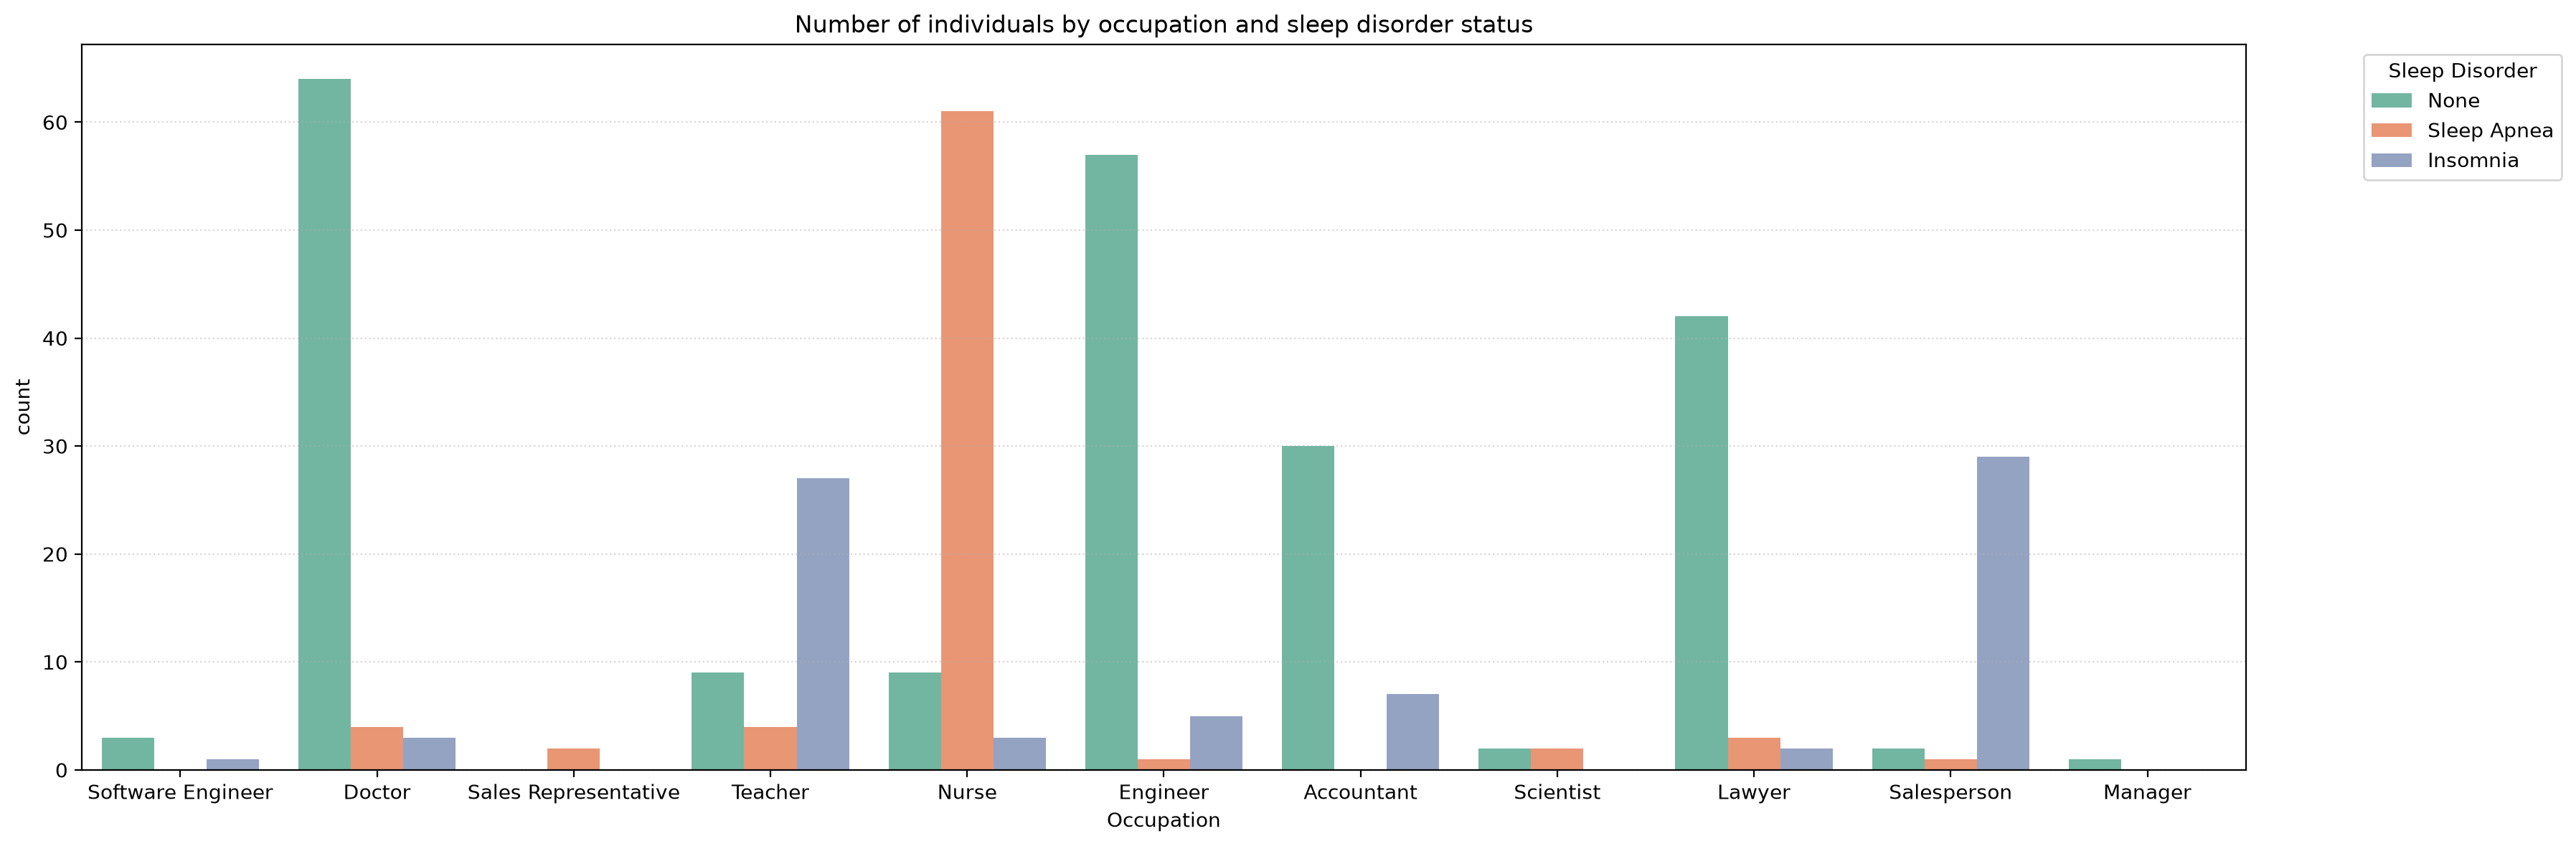

In [39]:
plt.figure(figsize=(18,6), dpi=200)
sns.countplot(data=df_without_nan, x='Occupation', hue='Sleep Disorder', palette='Set2')
plt.title('Number of individuals by occupation and sleep disorder status')
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc= 'upper left')
plt.grid(axis='y', linestyle = ':', alpha = 0.5 )
plt.tight_layout()

In [47]:
df_without_nan.groupby(by='Sleep Disorder')['Occupation'].value_counts()

Sleep Disorder  Occupation          
Insomnia        Salesperson             29
                Teacher                 27
                Accountant               7
                Engineer                 5
                Nurse                    3
                Doctor                   3
                Lawyer                   2
                Software Engineer        1
None            Doctor                  64
                Engineer                57
                Lawyer                  42
                Accountant              30
                Teacher                  9
                Nurse                    9
                Software Engineer        3
                Salesperson              2
                Scientist                2
                Manager                  1
Sleep Apnea     Nurse                   61
                Teacher                  4
                Doctor                   4
                Lawyer                   3
                S

In [50]:
df['Occupation'].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [52]:
df_without_nan['Sleep Disorder'].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

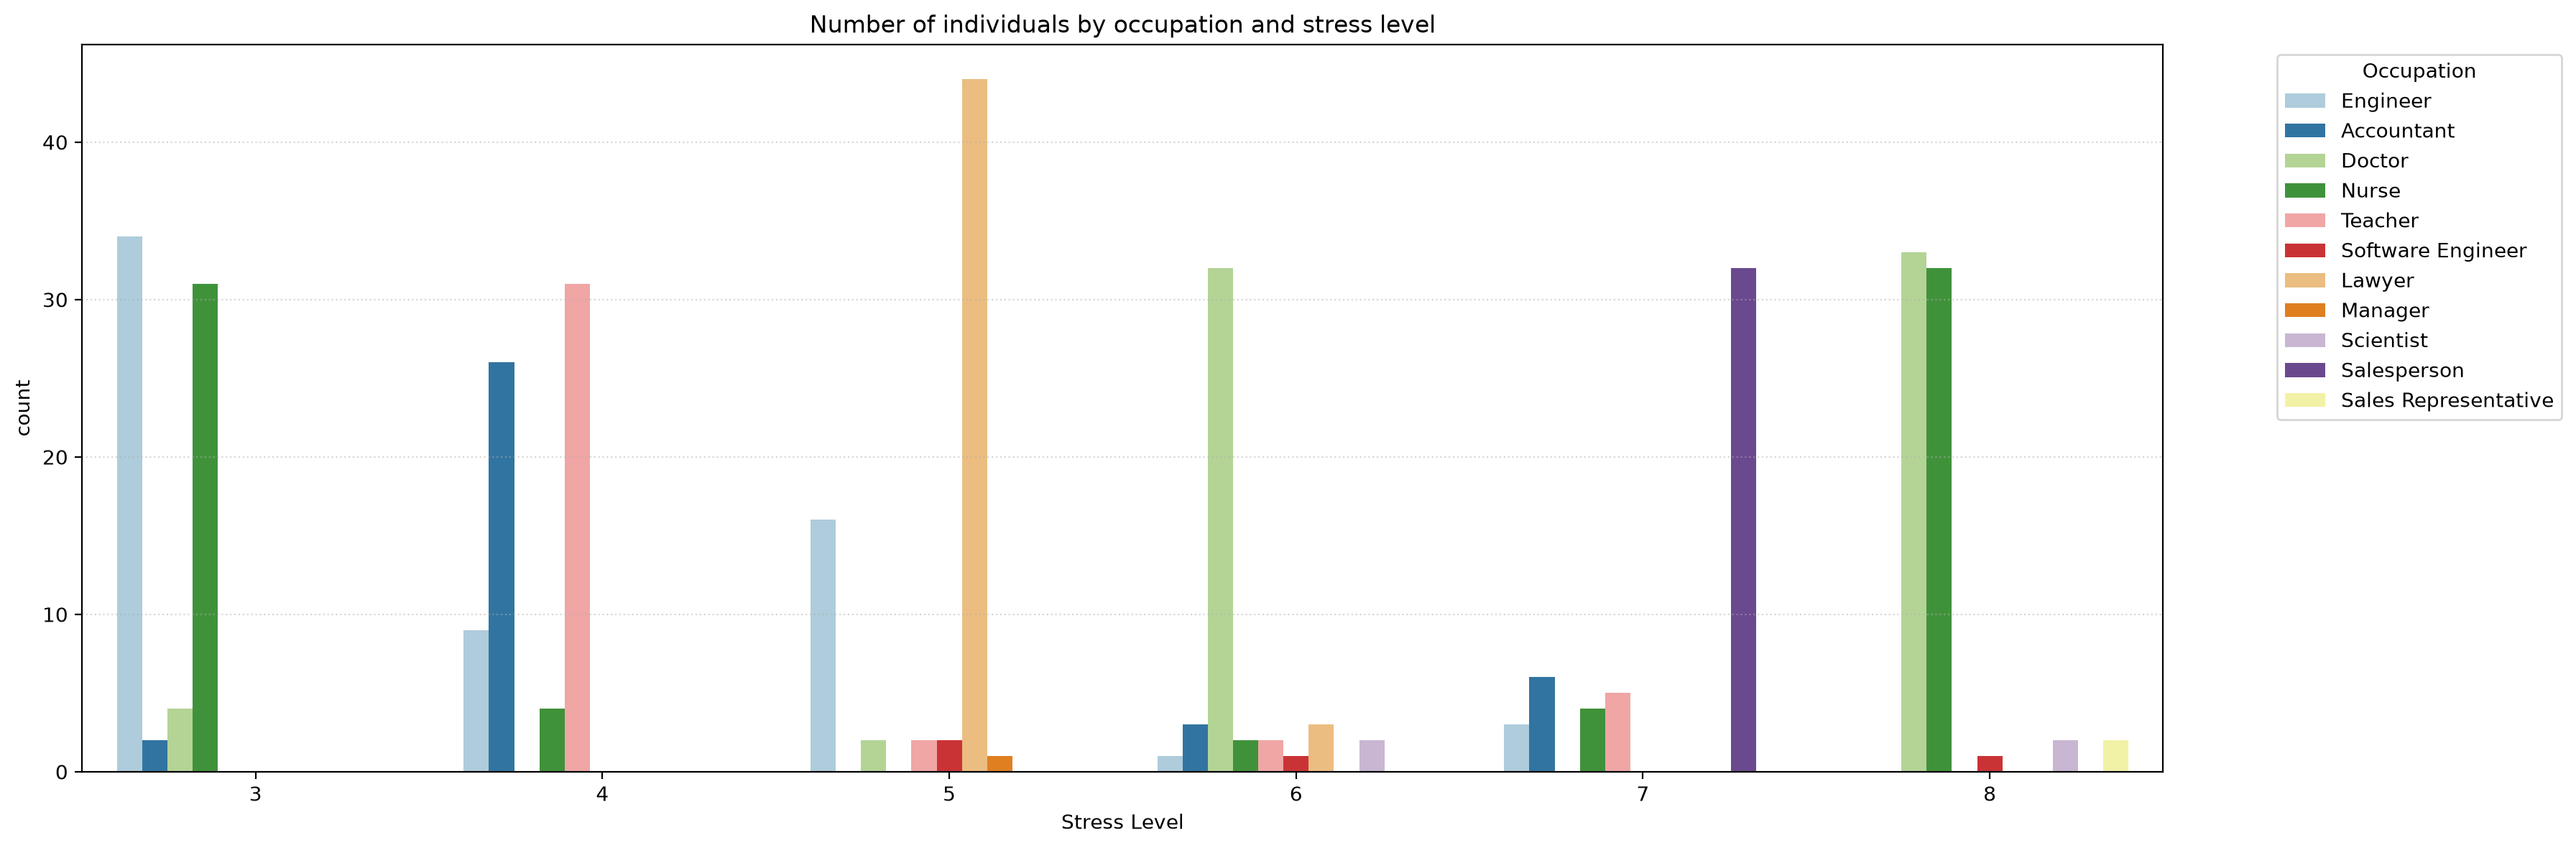

In [41]:
plt.figure(figsize=(18,6), dpi=200)
sns.countplot(data=df_without_nan, x='Stress Level', hue='Occupation', palette='Paired')
plt.title('Number of individuals by occupation and stress level')
plt.legend(title='Occupation', bbox_to_anchor=(1.05, 1), loc= 'upper left')
plt.grid(axis='y', linestyle = ':', alpha = 0.5 )
plt.tight_layout()

In [54]:
columns_to_show = ['Sleep Duration', 'Occupation', 'Age']
df_without_nan.groupby(by=['Stress Level','Sleep Disorder','Occupation'])[columns_to_show].agg({
    'Age': ['count', 'median'],
    'Sleep Duration': 'median'
})

Age        Sleep Duration
                                                 count median         median
Stress Level Sleep Disorder Occupation                                      
3            Insomnia       Engineer                 1   53.0           8.30
             None           Accountant               2   39.0           8.00
                            Doctor                   2   56.0           8.20
                            Engineer                33   53.0           8.40
                            Nurse                    3   59.0           8.10
             Sleep Apnea    Doctor                   2   49.0           8.10
                            Nurse                   28   58.5           8.10
4            Insomnia       Accountant               1   36.0           7.20
                            Teacher                 23   44.0           6.60
             None           Accountant              25   37.0           7.20
                            Engineer                 9   35.0           7.30
                            Nurse                    2   34.0           7.70
                            Teacher                  7   36.0           7.10
             Sleep Apnea    Nurse                    2   55.0           8.10
                            Teacher                  1   36.0           7.20
5            Insomnia       Doctor                   2   48.0           7.30
                            Engineer                 2   43.0           7.80
                            Lawyer                   2   40.0           7.40
             None           Engineer                13   43.0           7.80
                            Lawyer                  39   39.0           7.30
                            Manager                  1   45.0           6.90
                            Software Engineer        2   35.0           7.50
                            Teacher                  2   35.0           6.70
             Sleep Apnea    Engineer                 1   43.0           7.80
                            Lawyer                   3   38.0           7.40
6            Insomnia       Teacher                  2   45.0           6.80
             None           Accountant               3   40.0           7.20
                            Doctor                  31   31.0           7.70
                            Engineer                 1   41.0           7.30
                            Lawyer                   3   41.0           7.10
                            Nurse                    2   44.0           6.60
                            Scientist                2   33.0           6.20
                            Software Engineer        1   27.0           6.10
             Sleep Apnea    Doctor                   1   31.0           7.70
7            Insomnia       Accountant               6   52.0           6.60
                            Engineer                 2   41.5           6.65
                            Nurse                    2   29.5           6.45
                            Salesperson             29   44.0           6.40
                            Teacher                  2   32.5           6.45
             None           Engineer                 1   43.0           6.90
                            Salesperson              2   44.0           6.45
             Sleep Apnea    Nurse                    2   29.5           6.45
                            Salesperson              1   43.0           6.50
                            Teacher                  3   42.0           6.80
8            Insomnia       Doctor                   1   33.0           6.00
                            Nurse                    1   50.0           6.10
                            Software Engineer        1   28.0           5.90
             None           Doctor                  31   32.0           6.00
                            Nurse                    2   49.5           6.10
             Sleep Apnea    Doctor             

### Key observations from the bar graphs and tables:
To investigate occupation impact on sleep disorders, we analyzed both number of people with a certain profession grouped by sleep disorder and stress level.
* **Occupations associated with sleep disorders:**
  * `Insomnia` mostly occurs in teacher and salesperson occupation. 29 out of 40 teachers, that ~73%, have insomnia and 29 out of 32 salespersons, that ~91%, have it.
  * `Sleep Apnea` mostly accociated with nurse profession. 61 out of 73 nurses, that ~83% of all nurses and ~78% of all people with sleep apnea, have sleep apnea.

* **Occupations and stress levels.**
We observe the associations between stress levels and professions:
    1. **Stress level 3 (low stress):** The most concentrated nurse, who likely has a sleep apnea (that explains the spikes in apnea at level 3), and engineer occupation, who likely doesn't have any sleep disorders.
    2. **Stress level 4 (low stress):** The most concentrated accountant and teacher occupation. The teachers more likely have an insomnia, so that's why we observed the spikes in insomnia at stress level 4.
    3. **Stress level 5 (medium stress):** The most concentrated occupation is a lawyer, over 40 people.
    4. **Stress level 6 (medium stress):** The most concentrated occupation is a doctor, over 30 people.
    5. **Stress level 7 (high stress):** The most concentrated occupation is a salesperson, over 30 people. The salespersons are more likely to have an insomnia, so that's why we observed the spikes in insomnia at stress level 7.
    6. **Stress level 8 (high stress):** The most concentrated occupations are a doctor (who likely doesn't have any sleep disorders) and a nurse. Here again, the nurses are more likely to have an apnea, so that's why we observed the spikes in apnea at stress level 8. Interestingly, we observe the concentration of nurses as at the most low stress level and at the most high, so in this case, occupation doesn't strongly associate with one stress level but still strongly associate with sleep apnea.


# Conclusion on hypothesis testing

## Hypothesis #1: Physiological impact of stress
**Status: Confirmed**

Our analysis supports the first hypothesis about the physiological link between stress and heart rate:
* **Heart rate & stress:** There is a clear positive correlation showing that the higher the stress levels, the higher the heart rate.
* **Sleep quality & duration:** There is a clear negative correlation showing that higher heart rate and stress level associated with lower sleep quality and shorter sleep duration.
* **Sleep disorders & stress:** Sleep disorders don't directly correlate with stress levels. Instead, sleep disorders are clustered around specific occupations (e.g., `Sleep Apnea` in nurses, `Insomnia` in teachers and salespersons).
* **Physical activity & stress:** Tables show that there is no strong relationship between physical activity levels and stress levels in this dataset.
* **Age & stress:** Tables show that older people are most likely to experience less stress.

---

## Hypothesis #2: Compensatory sleep duration vs. sleep quality
**Status: Inconclusive / Partially Unsupported**

Our second hypothesis assumed that individuals under high stress might maintain or even increase their sleep duration to compensate for poor sleep quality:
* **Observations:** The data shows that high stress levels (7–8) generally correspond to both lower sleep quality and reduced sleep duration (dropping to ~6.0–6.5 hours). 
* **Data limitations:** The available metrics only track total `Sleep Duration` and do not measure sleep stages (e.g., time spent in light vs. deep sleep) or time spent in bed trying to fall asleep. 
* **Conclusion:** Based on the current dataset, we can't fully confirm if the body attempts to compensate for poor sleep quality by staying in bed longer. The evidence leans toward high stress reducing both sleep quality and quantity at the same time.